In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
#DM parameters 
rho_0_SI = 9.14 * 1e-25 #kg/m3
Rs_kpc = 135.0       # kpc
Rvir = 152.7 #kpc
centre = Rvir
n = 5.8
dn = 3*n - 1/3 + 0.0079/n

In [16]:
#natural unit covnersions 
#1 kg/m3 = 4.3101 * 10^-21 GeV^4
# 1 kpc = 1.5639 * 10^41 GeV^-1

rho_0 = rho_0_SI * 4.3 *1e-21 * 1e36 #eV^4
Rs = Rs_kpc * 1.5 *1e41 *1e-9 #ev^-1


In [17]:
r= np.logspace(-2,np.log10(2*Rvir),1000)   # 0.01 kpc to 305.4kpc

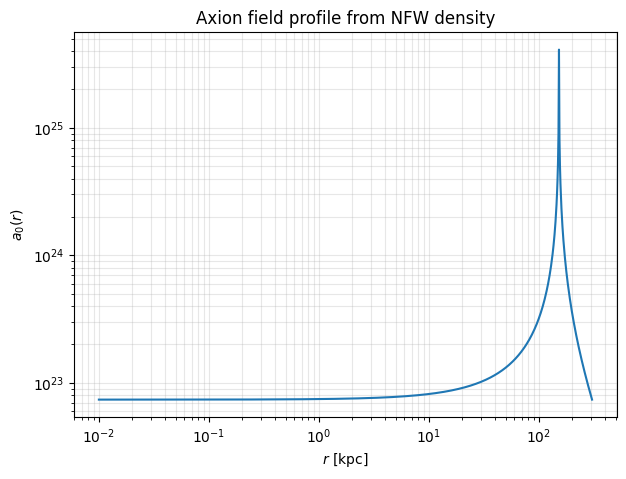

In [19]:
#Mass 
m_a = 1e-27#eV

#Density profile
def rho_DM(r): # NFW density
     return ( rho_0 * np.exp(-dn * ((np.abs(r-centre)/Rs_kpc)**(1/n) - 1)))

#axion field 
def a(r):
    return ( np.sqrt(2 * rho_DM(r)) / m_a )

# Plot
plt.figure(figsize=(7,5))
plt.loglog(r, a(r))

plt.xlabel(r'$r\ \mathrm{[kpc]}$')
plt.ylabel(r'$a_0(r)$')
plt.title(r'Axion field profile from NFW density')
plt.grid(True, which='both', alpha=0.3)

plt.show()


In [ ]:
#derivatives of a , in static, i.e taking cos =1 , sin=1
def a_dot(r):
    return ( -1* np.sqrt(2 * rho_0) * (r/Rs_kpc)**-0.5 * (1 + r/Rs_kpc)**-1  )

def a_prime(r):
    return ( ( np.sqrt(2 * rho_0) / ( m_a * Rs) ) * ((-0.5 * (r/Rs_kpc)**-1.5 * (1 + r/Rs_kpc)**-1) + (-1* (r/Rs_kpc)**-0.5 * (1 + r/Rs_kpc)**-2)))

plt.figure(figsize=(8, 6))

plt.loglog(r,a(r),lw=2,label=r'$a$')

plt.loglog(r,np.abs(a_prime(r)),'-',lw=2,label=r'$|a^\prime|$')

plt.loglog(r,np.abs(a_dot(r)),'-',lw=2,label=r'$|\dot a|$')

plt.loglog(r,np.abs(a_prime(r) - a_dot(r)),':',lw=2,label=r'$|a^\prime - \dot a|$')


plt.xlabel('log (r [kpc]', fontsize=12)
plt.ylabel('log(Axion field Amplitude)', fontsize=12)

plt.title(f"Axion profile based on NFW and derivatives at $m_a={m_a:.0e}$ eV")

plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()